In [42]:
import numpy as np
import matplotlib.pyplot as plt

In [43]:
from pathlib import Path
import h5py

diagnostics_path = Path("data/test_bursting_diagnostics.h5")
if not diagnostics_path.exists():
    raise FileNotFoundError("Run `python 02_run_test_diagnostics.py` first.")


def gamma_from_group(name):
    return float(name.removeprefix("gamma_").replace("m", "-").replace("p", "."))


with h5py.File(diagnostics_path, "r") as f:
    completed_step = int(f.attrs.get("completed_step", len(f["time/t"]) - 1))
    data_slice = slice(0, completed_step + 1)
    error_slice = slice(0, completed_step)
    t = f["time/t"][data_slice]
    gamma_groups = sorted(
        (name for name in f if name.startswith("gamma_")),
        key=gamma_from_group,
    )
    gamma_data = {
        gamma_from_group(name): {key: f[f"{name}/{key}"][data_slice] for key in f[name]}
        for name in gamma_groups
    }
    relative_l2_error = {
        gamma_from_group(name): f[f"errors/rel_l2_{name}"][error_slice]
        for name in gamma_groups
    }
    reference_enstrophy = f["etdrk4_ref/Enstrophy"][data_slice]

gammas = list(gamma_data)
r_magnitude = {gamma: np.abs(1.0 - data["q"]) for gamma, data in gamma_data.items()}
enstrophy = {gamma: data["Enstrophy"] for gamma, data in gamma_data.items()}
print(f"Loaded {len(gammas)} gamma values: {gammas}; T={t[-1]:g}")

Loaded 5 gamma values: [0.0, 50.0, 500.0, 1000.0, 2000.0]; T=20


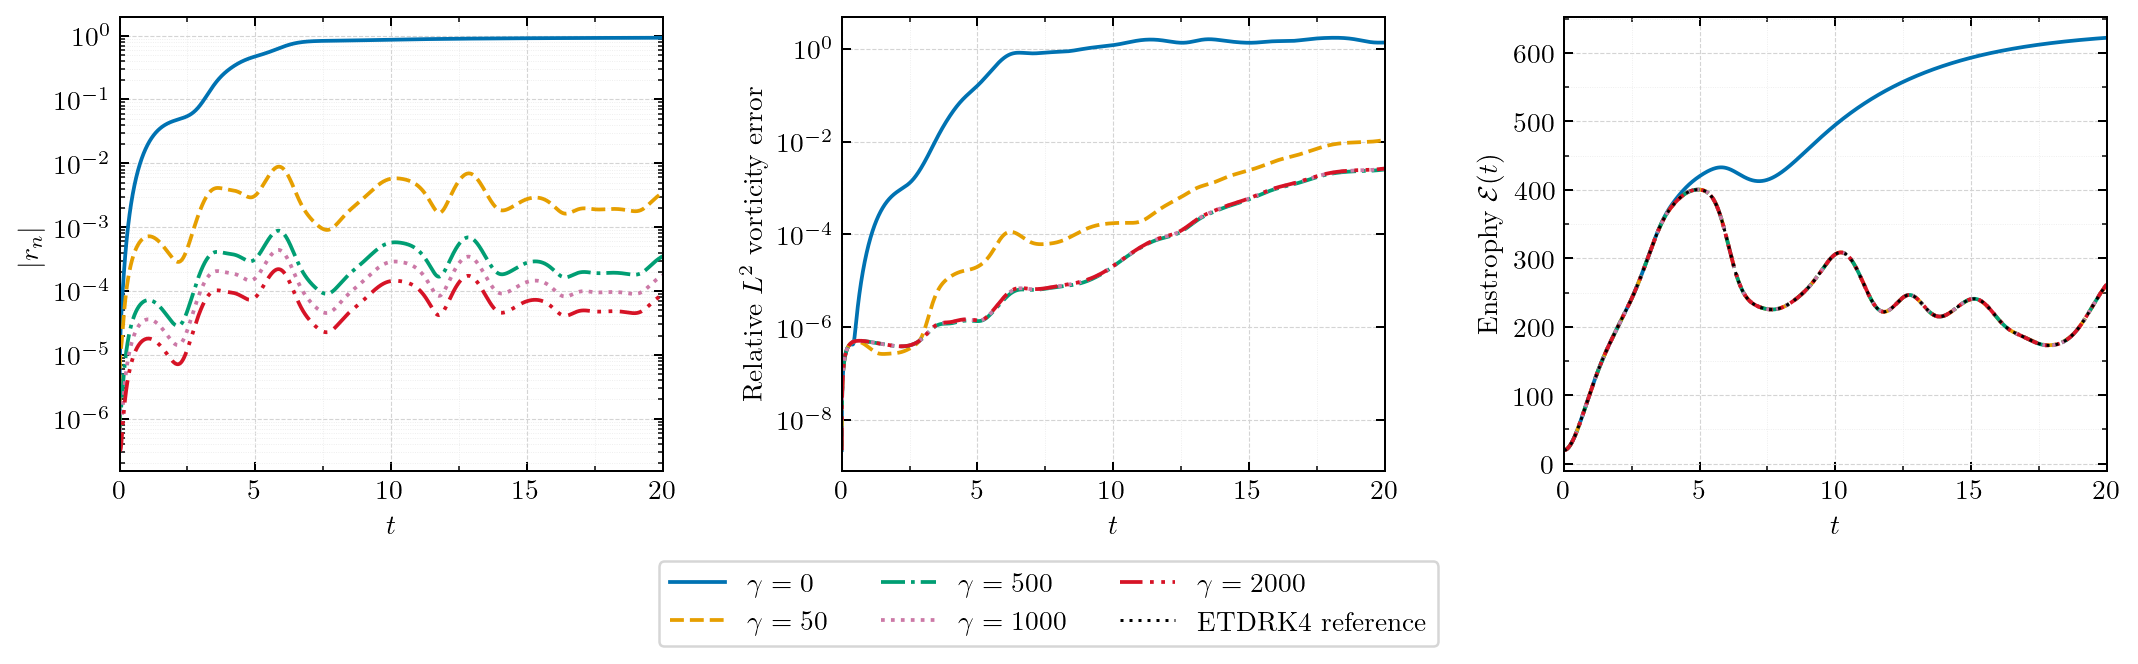

In [52]:
from matplotlib.ticker import AutoMinorLocator, LogLocator

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "mathtext.fontset": "stix",
    "xtick.direction": "in",
    "ytick.direction": "in",
})
Path("fig").mkdir(exist_ok=True)

colors = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D61326"]
linestyles = ["-", "--", "-.", ":", (0, (6, 2, 1, 2, 1, 2))]
styles = {
    gamma: {"color": colors[i % len(colors)], "ls": linestyles[i % len(linestyles)]}
    for i, gamma in enumerate(gammas)
}

def positive(values):
    values = np.asarray(values)
    return np.where(values > 0.0, values, np.nan)


fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.5), dpi=180)
for gamma in gammas:
    label = rf"$\gamma={gamma:g}$"
    axes[0].semilogy(t[1:], positive(r_magnitude[gamma][1:]), lw=1.5, label=label, **styles[gamma])
    axes[1].semilogy(t[1:], positive(relative_l2_error[gamma]), lw=1.5, label=label, **styles[gamma])
    axes[2].plot(t, enstrophy[gamma], lw=1.5, label=label, **styles[gamma])

axes[2].plot(t, reference_enstrophy, color="black", lw=1.2, ls=(0, (1, 2)), label="ETDRK4 reference")
axes[0].set_ylabel(r"$|r_n|$")
axes[1].set_ylabel(r"Relative $L^2$ vorticity error")
axes[2].set_ylabel(r"Enstrophy $\mathcal{E}(t)$")

for ax, panel in zip(axes, ["(a)", "(b)", "(c)"]):
    ax.set_xlabel(r"$t$")
    ax.set_xlim(t[0], t[-1])
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which="both", top=True, right=True)
    ax.grid(True, which="major", color="0.83", ls="--", lw=0.45)
    ax.grid(True, which="minor", color="0.92", ls=":", lw=0.35)
    # ax.text(0.02, 0.97, panel, transform=ax.transAxes, ha="left", va="top")

for ax in axes[:2]:
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
axes[2].yaxis.set_minor_locator(AutoMinorLocator(2))

handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=3)
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.25, top=0.97, wspace=0.33)
fig.savefig("fig/mrSAV_gamma_comparison.pdf", bbox_inches="tight")
fig.savefig("fig/mrSAV_gamma_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
import pandas as pd

selected_times = (4.0, 8.0, 16.0, 20.0)
gamma_blocks = ((0.0, 50.0), (500.0, 1000.0))
missing = {gamma for block in gamma_blocks for gamma in block} - set(gammas)
if missing:
    raise KeyError(f"Missing gamma data: {sorted(missing)}")


def time_index(target):
    index = int(np.argmin(np.abs(t - target)))
    if not np.isclose(t[index], target, rtol=0.0, atol=1e-12):
        raise ValueError(f"No diagnostic value stored at t={target:g}")
    return index


def diagnostics(gamma, target):
    index = time_index(target)
    if index == 0:
        raise ValueError("Relative vorticity errors are stored only for t[1:].")
    reference = reference_enstrophy[index]
    relative_enstrophy_error = abs(enstrophy[gamma][index] - reference) / abs(reference)
    return (
        r_magnitude[gamma][index],
        relative_l2_error[gamma][index - 1],
        relative_enstrophy_error,
    )


results = {
    gamma: {target: diagnostics(gamma, target) for target in selected_times}
    for block in gamma_blocks for gamma in block
}

for block in gamma_blocks:
    preview = pd.concat({
        rf"$\gamma={gamma:g}$": pd.DataFrame(
            [results[gamma][target] for target in selected_times],
            index=[f"{target:g}" for target in selected_times],
            columns=[r"$|r|$", r"$e_\omega$", r"$e_{\mathcal E}$"],
        ) for gamma in block
    }, axis=1)
    preview.index.name = r"$t$"
    display(preview.style.format("{:.3e}"))


def sci(value):
    if not np.isfinite(value):
        return r"\texttt{NaN}"
    if value == 0.0:
        return r"$0$"
    exponent = int(np.floor(np.log10(abs(value))))
    mantissa = value / 10.0**exponent
    return rf"${mantissa:.3f}\times10^{{{exponent}}}$"


def latex_block(gamma_left, gamma_right):
    lines = [
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{c *{6}{c}}",
        r"\toprule",
        rf"& \multicolumn{{3}}{{c}}{{$\gamma={gamma_left:g}$}} & \multicolumn{{3}}{{c}}{{$\gamma={gamma_right:g}$}} " + 2 * chr(92),
        r"\cmidrule(lr){2-4}\cmidrule(lr){5-7}",
        r"$t$ & $|r|$ & $e_\omega$ & $e_{\mathcal E}$ & $|r|$ & $e_\omega$ & $e_{\mathcal E}$ " + 2 * chr(92),
        r"\midrule",
    ]
    for target in selected_times:
        values = results[gamma_left][target] + results[gamma_right][target]
        lines.append(f"{target:g} & " + " & ".join(sci(value) for value in values) + " " + 2 * chr(92))
    lines.extend([r"\bottomrule", r"\end{tabular}%", r"}"] )
    return lines


latex_lines = [
    r"\begin{table}[htbp]",
    r"\centering",
    r"\caption{Diagnostics for the mean-reversion parameter experiment at selected times. The rows correspond to the time $t$, and the three columns grouped under each value of $\gamma$ report $|r|$, the relative vorticity error $e_\omega$, and the relative enstrophy error $e_{\mathcal E}$, respectively. The upper and lower tabular blocks contain the results for $(\gamma=0,100)$ and $(\gamma=1000,2000)$, respectively.}",
    r"\label{tab:gamma-effect}",
]
latex_lines.extend(latex_block(*gamma_blocks[0]))
latex_lines.append(r"\par\medskip")
latex_lines.extend(latex_block(*gamma_blocks[1]))
latex_lines.append(r"\end{table}")
latex_table = "\n".join(latex_lines)
Path("gamma_effect_table.tex").write_text(latex_table + "\n", encoding="utf-8")
print(latex_table)

\begin{table}[htbp]
\centering
\caption{Diagnostics for the mean-reversion parameter experiment at selected times. The rows correspond to the time $t$, and the three columns grouped under each value of $\gamma$ report $|r|$, the relative vorticity error $e_\omega$, and the relative enstrophy error $e_{\mathcal E}$, respectively. The upper and lower tabular blocks contain the results for $(\gamma=0,100)$ and $(\gamma=1000,2000)$, respectively.}
\label{tab:gamma-effect}
\resizebox{\textwidth}{!}{%
\begin{tabular}{c *{6}{c}}
\toprule
& \multicolumn{3}{c}{$\gamma=0$} & \multicolumn{3}{c}{$\gamma=50$} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}
$t$ & $|r|$ & $e_\omega$ & $e_{\mathcal E}$ & $|r|$ & $e_\omega$ & $e_{\mathcal E}$ \\
\midrule
4 & $2.887\times10^{-1}$ & $3.733\times10^{-2}$ & $7.489\times10^{-3}$ & $3.882\times10^{-3}$ & $1.228\times10^{-5}$ & $3.200\times10^{-6}$ \\
8 & $8.339\times10^{-1}$ & $8.716\times10^{-1}$ & $8.687\times10^{-1}$ & $1.117\times10^{-3}$ & $6.950\times10^{-5}$ 